In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import cv2, random, os
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import normalize
import math
import seaborn as sns
import numpy as np
import torchvision.transforms as T
import os
from urllib.parse import unquote
from torchvision.transforms import functional as TF
from tqdm import tqdm
import faiss
import sys, time

In [ ]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [5]:
train_df = pd.read_csv("/kaggle/input/datasets/kaggleju6se4pp/split-ready-data/train_split.csv")
val_df   = pd.read_csv("/kaggle/input/datasets/kaggleju6se4pp/split-ready-data/val_split.csv")
val_gt  = pd.read_csv("/kaggle/input/datasets/kaggleju6se4pp/split-ready-data/val_gt.csv")

In [6]:
TRAIN_DIR = Path("/kaggle/input/competitions/landmark-recognition-2021/train")
TEST_DIR  = Path("/kaggle/input/competitions/landmark-recognition-2021/test")

In [7]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
torch.backends.cudnn.benchmark = True

In [8]:
def make_subset(df, frac=0.05, seed=42):
    df = df.sample(frac=frac, random_state=seed).reset_index(drop=True)
    return df

def split_train_val_by_class(df, val_ratio=0.2, seed=42):
    train_parts = []
    val_parts = []

    rng = np.random.RandomState(seed)

    for cls, g in df.groupby("landmark_id"):
        g = g.sample(frac=1, random_state=seed).reset_index(drop=True)
        n = len(g)

        if n == 1:
            train_parts.append(g)
            continue

        n_val = max(1, int(round(n * val_ratio)))
        if n_val >= n:
            n_val = n - 1

        val_idx = rng.choice(n, size=n_val, replace=False)
        val_mask = np.zeros(n, dtype=bool)
        val_mask[val_idx] = True

        val_parts.append(g[val_mask])
        train_parts.append(g[~val_mask])

    train_df = pd.concat(train_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    val_df = pd.concat(val_parts).sample(frac=1, random_state=seed).reset_index(drop=True) if val_parts else pd.DataFrame(columns=df.columns)

    return train_df, val_df

In [ ]:
CFG = {
    'backbone': 'tf_efficientnet_b3',
    'embedding_size': 256,
    'batch_size': 64,
    'image_size': 256,
    'epochs': 5,
    'lr': 0.0001,
    'margin': 0.3,
    'scale': 20.0,
    'device': 'cuda'
}

In [10]:
class LandmarkDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def load_image(self, img_id):
        path = self.img_dir / img_id[0] / img_id[1] / img_id[2] / f"{img_id}.jpg"
        img = Image.open(path).convert("RGB")
        return ImageOps.exif_transpose(img)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self.load_image(row["id"])
        if self.transform:
            img = self.transform(img)
        label = int(row["label_idx"])
        return img, torch.tensor(label, dtype=torch.long)

In [ ]:
train_tfms = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    T.RandomRotation(degrees=15),
    T.CenterCrop(CFG["image_size"]),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomHorizontalFlip()
])

val_tfms = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomHorizontalFlip()
])

In [12]:
print(f"Исходный train: {len(train_df)}, val: {len(val_df)}")

train_clean = train_df[train_df['landmark_id'] != -1].copy()
val_clean   = val_df[val_df['landmark_id'] != -1].copy()

print(f"После удаления дистракторов train: {len(train_clean)}, val: {len(val_clean)}")


top500_classes = train_clean['landmark_id'].value_counts().head(500).index
train_top = train_clean[train_clean['landmark_id'].isin(top500_classes)].copy()
val_top   = val_clean[val_clean['landmark_id'].isin(top500_classes)].copy()

print(f"Топ-500: train {len(train_top)} изображений, val {len(val_top)} изображений")
print(f"Число классов: {len(top500_classes)}")



unique_labels = sorted(train_top['landmark_id'].unique())
label2idx = {l: i for i, l in enumerate(unique_labels)}
idx2label = {i: l for l, i in label2idx.items()}
num_classes = len(label2idx)
print(f"Уникальных классов в топ-500: {num_classes}")



train_top['label_idx'] = train_top['landmark_id'].map(label2idx)
val_top['label_idx']   = val_top['landmark_id'].map(label2idx)

Исходный train: 1057798, val: 317340
После удаления дистракторов train: 1057798, val: 264450
Топ-500: train 117239 изображений, val 29442 изображений
Число классов: 500
Уникальных классов в топ-500: 500


In [13]:
train_ds = LandmarkDataset(train_top, TRAIN_DIR, transform=train_tfms)
val_ds   = LandmarkDataset(val_top, TRAIN_DIR, transform=val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [15]:
class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * float(p))
        self.eps = eps

    def forward(self, x):
        return x.clamp(min=self.eps).pow(self.p).mean(dim=(-1, -2)).pow(1.0 / self.p)

In [16]:
class EmbeddingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            CFG["backbone"],
            pretrained=True,
            num_classes=0
        )
        self.pool = GeM(3.0)
        self.fc = nn.Linear(self.backbone.num_features, CFG["embedding_size"])
        self.bn = nn.BatchNorm1d(CFG["embedding_size"])
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.pool(x)
        x = self.fc(x)
        x = self.dropout(x)
        x = self.bn(x)
        return F.normalize(x, dim=1)

In [17]:
class ArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_size, margin=0.5, scale=64.0):
        super().__init__()
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        weight_norm = F.normalize(self.weight, dim=1)
        embeddings_norm = F.normalize(embeddings, dim=1)
        cosine = F.linear(embeddings_norm, weight_norm)

        labels = labels.long()
        assert labels.min() >= 0 and labels.max() < self.num_classes, "Метка вне допустимого диапазона"

        theta = torch.acos(torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7))
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1)
        theta_with_margin = theta + one_hot * self.margin
        output = torch.cos(theta_with_margin) * self.scale
        return F.cross_entropy(output, labels)

In [ ]:
class PartialArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_size, margin=0.3, scale=30.0,
                 neg_class_num=2048):
        super().__init__()
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        self.neg_class_num = neg_class_num

        self.W = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.W)

        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin

    def forward(self, embeddings, labels):
        W_norm = F.normalize(self.W)

        pos_classes = torch.unique(labels)
        if self.neg_class_num > 0 and len(pos_classes) < self.neg_class_num:
            all_classes = torch.arange(self.num_classes, device=embeddings.device)
            mask = torch.ones(self.num_classes, dtype=torch.bool, device=embeddings.device)
            mask[pos_classes] = False
            neg_pool = all_classes[mask]
            if len(neg_pool) > 0:
                num_neg = min(self.neg_class_num - len(pos_classes), len(neg_pool))
                neg_classes = neg_pool[torch.randperm(len(neg_pool))[:num_neg]]
            else:
                neg_classes = torch.tensor([], dtype=torch.long, device=embeddings.device)
            sub_classes = torch.cat([pos_classes, neg_classes])
        else:
            sub_classes = torch.arange(self.num_classes, device=embeddings.device)

        sub_W = W_norm[sub_classes]

        sub_class_to_idx = {cls.item(): i for i, cls in enumerate(sub_classes)}
        mapped_labels = torch.tensor([sub_class_to_idx[l.item()] for l in labels],
                                     device=labels.device, dtype=torch.long)

        cosine = F.linear(embeddings, sub_W)

        sine = torch.sqrt((1.0 - cosine**2).clamp(0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, mapped_labels.view(-1, 1), 1)

        logits = one_hot * phi + (1 - one_hot) * cosine
        logits *= self.scale

        loss = F.cross_entropy(logits, mapped_labels)
        return loss

In [19]:
def average_precision(gt_label, preds):
    for i, (pred_label, _) in enumerate(preds, 1):
        if pred_label == gt_label:
            return 1.0 / i
    return 0.0

In [20]:
def compute_gap(prediction_strings, gt_labels):
    ap_sum = 0.0

    for pred_str, gt in zip(prediction_strings, gt_labels):
        if not pred_str.strip():
            ap = 0.0
        else:
            parts = pred_str.strip().split()
            pred_list = []

            for p in range(0, len(parts), 2):
                lbl = int(parts[p])
                conf = float(parts[p+1])
                pred_list.append((lbl, conf))

            pred_list.sort(key=lambda x: x[1], reverse=True)
            ap = average_precision(gt, pred_list)

        ap_sum += ap

    return ap_sum / len(gt_labels)

In [21]:
def get_prediction_strings(logits, topk=5):
    probs = logits.softmax(dim=1)
    topk_vals, topk_idx = probs.topk(topk, dim=1)

    results = []

    for vals, idxs in zip(topk_vals, topk_idx):
        parts = []
        for v, i in zip(vals, idxs):
            parts.append(f"{int(i)} {float(v)}")
        results.append(" ".join(parts))

    return results

In [ ]:
@torch.no_grad()
def get_embeddings(model, loader):
    model.eval()

    all_embs = []
    all_labels = []

    for imgs, labels in loader:
        imgs = imgs.to(CFG["device"])

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            emb = model(imgs)

        all_embs.append(emb.cpu())
        all_labels.extend(labels.numpy())

    all_embs = torch.cat(all_embs, dim=0)  # [N, D]
    all_labels = torch.tensor(all_labels)

    return all_embs, all_labels

In [23]:
@torch.no_grad()
def evaluate_gap_knn(model, train_loader, val_loader, topk=5):
    model.eval()

    train_embs, train_labels = get_embeddings(model, train_loader)
    train_embs = F.normalize(train_embs, dim=1)
    train_labels_np = train_labels.cpu().numpy()

    all_preds = []
    all_gts = []

    for imgs, labels in val_loader:
        imgs = imgs.to(CFG["device"])
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            val_embs = model(imgs).cpu()
        val_embs = F.normalize(val_embs, dim=1)

        sim = val_embs @ train_embs.T

        topk_vals, topk_idx = sim.topk(topk, dim=1)

        for vals, idxs, gt in zip(topk_vals, topk_idx, labels):
            unique = {}
            for v, idx in zip(vals, idxs):
                lbl = int(train_labels_np[idx])
                conf = float(v)
                if lbl not in unique or conf > unique[lbl]:
                    unique[lbl] = conf

            sorted_items = sorted(unique.items(), key=lambda x: x[1], reverse=True)[:topk]
            parts = [f"{lbl} {conf}" for lbl, conf in sorted_items]
            all_preds.append(" ".join(parts))
            all_gts.append(gt.item())

    for i in range(min(5, len(all_preds))):
        print(f"\n--- Sample {i} (GT={all_gts[i]}) ---")
        parts = all_preds[i].split()
        for p in range(0, len(parts), 2):
            print(f"  Pred: {parts[p]} conf={float(parts[p+1]):.4f}")

    return compute_gap(all_preds, all_gts)

In [24]:
print(CFG)

{'backbone': 'tf_efficientnet_b3', 'embedding_size': 256, 'batch_size': 64, 'image_size': 256, 'epochs': 5, 'lr': 0.0001, 'margin': 0.3, 'scale': 20.0, 'device': 'cuda'}


In [ ]:
start = time.time()
imgs, labels = next(iter(train_loader))
print("Batch load time:", time.time() - start)

Batch load time: 7.225155591964722


In [ ]:
for imgs, labels in train_loader:
    break

start = time.time()
for i, (imgs, labels) in zip(range(10), train_loader):
    pass
total = time.time() - start
print(f"10 batches: {total:.2f} sec, average per batch: {total/10:.3f} sec")

10 batches: 12.37 sec, average per batch: 1.237 sec


In [57]:
CFG["batch_size"] = 8
ACCUMULATION_STEPS = 2

In [59]:
CFG['epochs'] = 15

In [ ]:
model = EmbeddingNet().to(CFG["device"])
criterion = PartialArcFaceLoss(
    num_classes=len(label2idx),
    embedding_size=CFG["embedding_size"],
    margin=CFG["margin"],
    scale=CFG["scale"],
    neg_class_num=1024
).to(CFG["device"])

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=CFG["lr"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["epochs"]
)

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

imgs, labels = next(iter(train_loader))
imgs = imgs.to(CFG["device"])
labels = labels.to(CFG["device"])

with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
    emb = model(imgs)
    loss = criterion(emb, labels)

if torch.isnan(loss):
    print("NaN detected!")
    raise ValueError("NaN in loss")

print("Sanity check OK:", emb.shape, loss.item())

best_val_gap = 0.0

for epoch in range(CFG["epochs"]):
    print(torch.cuda.memory_summary(device=CFG["device"], abbreviated=True))
    model.train()
    criterion.train()
    total_loss = 0.0
    total = 0
    optimizer.zero_grad()

    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}', file=sys.stdout, mininterval=1.0)
    for batch_idx, (imgs, labels) in enumerate(loop):
        imgs = imgs.to(CFG["device"], non_blocking=True)
        labels = labels.to(CFG["device"], non_blocking=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            embeddings = model(imgs)
            loss = criterion(embeddings, labels)

        loss = loss / ACCUMULATION_STEPS
        scaler.scale(loss).backward()

        bs = labels.size(0)
        total_loss += loss.item() * bs * ACCUMULATION_STEPS
        total += bs

        if (batch_idx + 1) % ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        if (batch_idx + 1) % 10 == 0:
            loop.set_postfix(loss=loss.item() * ACCUMULATION_STEPS)  # показываем исходный loss
            sys.stdout.flush()
        del embeddings, loss
        torch.cuda.empty_cache()

    if (batch_idx + 1) % ACCUMULATION_STEPS != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    train_loss = total_loss / max(total, 1)

    val_gap = evaluate_gap_knn(model, train_loader, val_loader, topk=5)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_gap={val_gap:.4f}")

    if val_gap > best_val_gap:
        best_val_gap = val_gap
        torch.save({
            "model": model.state_dict(),
            "criterion": criterion.state_dict(),
            "label2idx": label2idx,
            "idx2label": idx2label,
            "cfg": CFG,
        }, "/kaggle/working/best_arcface_debug.pth")
        print("Saved best checkpoint")

    scheduler.step()

--- Sample 0 (GT=102) ---
  Pred: 74 conf=0.7021
  Pred: 453 conf=0.6752
  Pred: 452 conf=0.6749
  Pred: 151 conf=0.6717

--- Sample 1 (GT=261) ---
  Pred: 261 conf=0.8132
  Pred: 280 conf=0.7534

--- Sample 2 (GT=215) ---
  Pred: 215 conf=0.8838

--- Sample 3 (GT=22) ---
  Pred: 22 conf=0.8277
  Pred: 390 conf=0.7782

--- Sample 4 (GT=107) ---
  Pred: 253 conf=0.8439
  Pred: 107 conf=0.8015
  Pred: 74 conf=0.7992
Epoch 1: train_loss=9.5252 val_gap=0.7054


--- Sample 0 (GT=102) ---
  Pred: 325 conf=0.5791
  Pred: 424 conf=0.5616
  Pred: 258 conf=0.5608
  Pred: 441 conf=0.5536
  Pred: 446 conf=0.5535

--- Sample 1 (GT=261) ---
  Pred: 261 conf=0.7627

--- Sample 2 (GT=215) ---
  Pred: 215 conf=0.9367

--- Sample 3 (GT=22) ---
  Pred: 22 conf=0.8726

--- Sample 4 (GT=107) ---
  Pred: 253 conf=0.8409
  Pred: 107 conf=0.8239
Epoch 2: train_loss=6.1477 val_gap=0.7903


--- Sample 0 (GT=102) ---
  Pred: 102 conf=0.6371
  Pred: 199 conf=0.5804
  Pred: 367 conf=0.5783
  Pred: 0 conf=0.5781

--- Sample 1 (GT=261) ---
  Pred: 261 conf=0.8519

--- Sample 2 (GT=215) ---
  Pred: 215 conf=0.9442

--- Sample 3 (GT=22) ---
  Pred: 22 conf=0.8272

--- Sample 4 (GT=107) ---
  Pred: 107 conf=0.8251
  Pred: 253 conf=0.8244
Epoch 3: train_loss=4.5675 val_gap=0.8224

--- Sample 0 (GT=102) ---
  Pred: 0 conf=0.6093
  Pred: 323 conf=0.5773
  Pred: 374 conf=0.5593
  Pred: 424 conf=0.5565

--- Sample 1 (GT=261) ---
  Pred: 261 conf=0.8187

--- Sample 2 (GT=215) ---
  Pred: 215 conf=0.9601

--- Sample 3 (GT=22) ---
  Pred: 22 conf=0.8853

--- Sample 4 (GT=107) ---
  Pred: 253 conf=0.8399
  Pred: 107 conf=0.7932
Epoch 4: train_loss=3.6126 val_gap=0.8388
--- Sample 0 (GT=102) ---
  Pred: 102 conf=0.5732
  Pred: 31 conf=0.5455
  Pred: 155 conf=0.5054
  Pred: 367 conf=0.4953

--- Sample 1 (GT=261) ---
  Pred: 261 conf=0.8508

--- Sample 2 (GT=215) ---
  Pred: 215 conf=0.9524

--- Sample 3 (GT=22) ---
  Pred: 22 conf=0.8793

--- Sample 4 (GT=107) ---
  Pred: 253 conf=0.7891
  Pred: 84 conf=0.7310
  Pred: 107 conf=0.7151
  Pred: 357 conf=0.7006
  Pred: 443 conf=0.6919
Epoch 5: train_loss=2.9629 val_gap=0.8442

--- Sample 0 (GT=102) ---
  Pred: 0 conf=0.6005
  Pred: 258 conf=0.5541
  Pred: 102 conf=0.5265
  Pred: 464 conf=0.5181
  Pred: 424 conf=0.5164

--- Sample 1 (GT=261) ---
  Pred: 261 conf=0.8553

--- Sample 2 (GT=215) ---
  Pred: 215 conf=0.9647

--- Sample 3 (GT=22) ---
  Pred: 22 conf=0.8955

--- Sample 4 (GT=107) ---
  Pred: 253 conf=0.7708
  Pred: 107 conf=0.7332
  Pred: 443 conf=0.6845
Epoch 6: train_loss=2.4652 val_gap=0.8520


In [2]:
import matplotlib.pyplot as plt

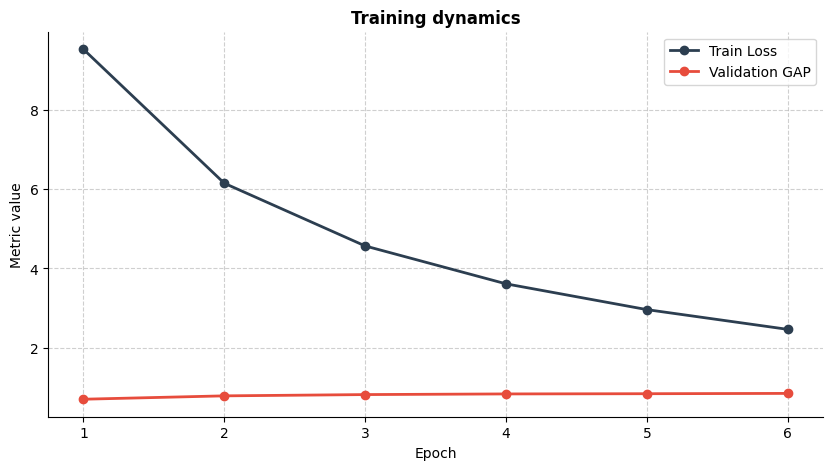

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

epochs = [1, 2, 3, 4, 5, 6]

train_loss = [9.5252, 6.1477, 4.5675, 3.6126, 2.9629, 2.4652]
val_gap = [0.7054, 0.7903, 0.8224, 0.8388, 0.8442, 0.8520]

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_loss, marker='o', label='Train Loss',
         color='#2c3e50', linewidth=2, markersize=6)
plt.plot(epochs, val_gap, marker='o', label='Validation GAP',
         color='#e74c3c', linewidth=2, markersize=6)

plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Training dynamics", fontweight='bold')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

sns.despine()

plt.show()

In [ ]:
index_tfms = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_index_ds = LandmarkDataset(train_top, TRAIN_DIR, transform=index_tfms)
train_index_loader = DataLoader(
    train_index_ds,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [ ]:
device = CFG["device"]
@torch.no_grad()
def get_all_embeddings(loader, model):
    model.eval()
    all_embs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="Extracting train embeddings"):
        imgs = imgs.to(device)
        emb = model(imgs)
        all_embs.append(emb.cpu())
        all_labels.extend(labels.numpy())
    return torch.cat(all_embs, dim=0), np.array(all_labels)

train_embs, train_labels_idx = get_all_embeddings(train_index_loader, model)
train_embs = F.normalize(train_embs, dim=1).numpy().astype('float32')
print(f"Train embeddings shape: {train_embs.shape}")

In [ ]:
dim = train_embs.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(train_embs)
print(f"Index built with {index.ntotal} vectors")

In [ ]:
class TestDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def load_image(self, img_id):
        path = self.img_dir / img_id[0] / img_id[1] / img_id[2] / f"{img_id}.jpg"
        img = Image.open(path).convert("RGB")
        return ImageOps.exif_transpose(img)

    def __getitem__(self, idx):
        img_id = self.df.loc[idx, "id"]
        img = self.load_image(img_id)
        if self.transform:
            img = self.transform(img)
        return img, img_id

test_tfms = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_df = pd.read_csv("/kaggle/input/competitions/landmark-recognition-2021/sample_submission.csv")
test_ds = TestDataset(test_df, TEST_DIR, transform=test_tfms)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
@torch.no_grad()
def predict_test_tta(model, test_loader, faiss_index, train_labels_idx, idx2label, topk=100, threshold=0.0):
    model.eval()
    test_ids = []
    pred_strings = []

    for imgs, img_ids in tqdm(test_loader, desc="Predicting test with TTA"):
        imgs = imgs.to(device)  # [B, C, H, W]

        imgs_tta = []
        imgs_tta.append(imgs)
        imgs_tta.append(torch.flip(imgs, dims=[3]))
        imgs_tta.append(TF.rotate(imgs, angle=15, fill=0))
        imgs_tta.append(TF.rotate(imgs, angle=-15, fill=0))

        # (B*4, C, H, W)
        imgs_stacked = torch.cat(imgs_tta, dim=0)

        emb_all = model(imgs_stacked)                # [B*4, D]
        emb_all = F.normalize(emb_all, dim=1)

        B = imgs.size(0)
        emb_avg = emb_all.view(4, B, -1).mean(dim=0) # [B, D]

        emb_np = emb_avg.cpu().numpy().astype('float32')
        D, I = faiss_index.search(emb_np, topk)

        for i in range(B):
            label_conf = {}
            for j in range(topk):
                lbl_idx = train_labels_idx[I[i, j]]
                lbl = idx2label[lbl_idx]
                conf = float(D[i, j])
                if lbl not in label_conf or conf > label_conf[lbl]:
                    label_conf[lbl] = conf
            sorted_items = sorted(label_conf.items(), key=lambda x: x[1], reverse=True)
            if sorted_items and sorted_items[0][1] >= threshold:
                pred_str = " ".join(f"{lbl} {conf:.6f}" for lbl, conf in sorted_items[:100])
            else:
                pred_str = ""
            pred_strings.append(pred_str)
            test_ids.append(img_ids[i])

    return test_ids, pred_strings
test_ids, pred_strings = predict_test_tta(model, test_loader, index, train_labels_idx, idx2label,
                                      topk=100, threshold=0.3)

In [ ]:
@torch.no_grad()
def predict_test(model, test_loader, faiss_index, train_labels_idx, idx2label, topk=100, threshold=0.0):
    model.eval()
    test_ids = []
    pred_strings = []

    for imgs, img_ids in tqdm(test_loader, desc="Predicting test"):
        imgs = imgs.to(device)
        emb1 = model(imgs)
        emb2 = model(torch.flip(imgs, dims=[3]))
        emb = (emb1 + emb2) / 2.0
        emb = F.normalize(emb, dim=1).cpu().numpy().astype('float32')

        D, I = faiss_index.search(emb, topk)

        for i in range(len(D)):
            label_conf = {}
            for j in range(topk):
                lbl_idx = train_labels_idx[I[i, j]]
                lbl = idx2label[lbl_idx]
                conf = float(D[i, j])
                if lbl not in label_conf or conf > label_conf[lbl]:
                    label_conf[lbl] = conf
            sorted_items = sorted(label_conf.items(), key=lambda x: x[1], reverse=True)
            if sorted_items and sorted_items[0][1] >= threshold:
                pred_str = " ".join(f"{lbl} {conf:.6f}" for lbl, conf in sorted_items[:100])
            else:
                pred_str = ""
            pred_strings.append(pred_str)
            test_ids.append(img_ids[i])

    return test_ids, pred_strings

test_ids, pred_strings = predict_test(model, test_loader, index, train_labels_idx, idx2label,
                                      topk=100, threshold=0.3)

In [ ]:
submission = pd.DataFrame({"id": test_ids, "landmarks": pred_strings})
sample_sub = pd.read_csv("/kaggle/input/competitions/landmark-recognition-2021/sample_submission.csv")
submission = sample_sub[["id"]].merge(submission, on="id", how="left")
submission["landmarks"] = submission["landmarks"].fillna("")
submission.to_csv("submission_minimal.csv", index=False)
print("Файл submission_minimal.csv сохранён!")

In [ ]:
submission.head()

In [ ]:
info_path = "/kaggle/input/datasets/kaggleju6se4pp/categories/train_label_to_category.csv"

info_df = pd.read_csv(info_path)

id_to_name = dict(zip(info_df["landmark_id"], info_df["category"]))

print(f"Загружено {len(id_to_name)} категорий")

In [ ]:
info_path = "/kaggle/input/datasets/kaggleju6se4pp/categories/train_label_to_category.csv"
info_df = pd.read_csv(info_path)

def clean_category_name(category_url: str) -> str:
    name_part = category_url.rsplit('Category:', 1)[-1]
    name_part = name_part.rstrip('/')
    name_part = unquote(name_part)
    name_part = name_part.replace('_', ' ')
    return name_part

id_to_name = {}
for _, row in info_df.iterrows():
    lid = row['landmark_id']
    raw = row['category']
    id_to_name[lid] = clean_category_name(raw)

print(f"Загружено {len(id_to_name)} читаемых названий")

In [ ]:
for idx in range(5):
    img_id = test_ids[idx]
    preds = pred_strings[idx]

    print(f"\n===== Изображение {img_id} =====")
    if not preds.strip():
        print("  Нет предсказаний")
        continue

    parts = preds.strip().split()
    for p in range(0, len(parts), 2):
        landmark_id_str = parts[p]
        conf_str = parts[p+1]
        landmark_id = int(landmark_id_str)
        name = id_to_name.get(landmark_id, f"Неизвестный ID {landmark_id}")
        print(f"  {name:<40s}  уверенность: {float(conf_str):.4f}")

In [ ]:
@torch.no_grad()
def get_embeddings(model, loader, max_batches=None):
    model.eval()

    all_embs = []
    all_labels = []

    for batch_idx, (imgs, labels) in enumerate(loader):

        print(f"batch {batch_idx+1}")

        imgs = imgs.to(CFG["device"])

        with torch.amp.autocast(
            "cuda",
            enabled=torch.cuda.is_available()
        ):
            emb = model(imgs)

        all_embs.append(emb.cpu())
        all_labels.extend(labels.numpy())

        if max_batches is not None:
            if batch_idx + 1 >= max_batches:
                print(f"STOP at batch {max_batches}")
                break

    all_embs = torch.cat(all_embs, dim=0)
    all_labels = torch.tensor(all_labels)

    return all_embs, all_labels

## Изображение 00084cdf8f600d00
- Zvartnots — уверенность: 0.5693
- Mount Wutai — уверенность: 0.5534
- Lake Lucerne — уверенность: 0.5322
- Market Square, Lviv — уверенность: 0.5293
- Stonehenge — уверенность: 0.5019
- Kissimmee Air Museum — уверенность: 0.4905
- Media contributed by the ETH-Bibliothek — уверенность: 0.4885
- Trevi fountain — уверенность: 0.4867
- Saiful Muluk Lake — уверенность: 0.4864
- Salève — уверенность: 0.4824
- Olympiastadion Berlin — уверенность: 0.4766
- Tatev — уверенность: 0.4747
- Begnas Lake — уверенность: 0.4730
- Ternopil Pond — уверенность: 0.4702
- Palace of Culture and Science — уверенность: 0.4682
- National World War II Memorial — уверенность: 0.4655
- Khimki Reservoir — уверенность: 0.4650
- Hadrian's Wall — уверенность: 0.4627
- Bolków Castle — уверенность: 0.4625
- Narikala — уверенность: 0.4621
- Lake Wendouree — уверенность: 0.4599
- Rocks of MODR — уверенность: 0.4567
- Pont du Gard — уверенность: 0.4556
- Jurassic Coast — уверенность: 0.4537
- Alexander Nevsky Cathedral, Sofia — уверенность: 0.4519
- Madikwe Game Reserve — уверенность: 0.4516
- Flensburg harbour — уверенность: 0.4516
- Huangshan — уверенность: 0.4508
- La Dôle — уверенность: 0.4503
- Grand Canyon — уверенность: 0.4498
- Pidhirtsi Castle — уверенность: 0.4474
- Hoensbroek Castle — уверенность: 0.4469
- Bara Imambara — уверенность: 0.4462
- Attabad Lake — уверенность: 0.4461
- Your liberators, Donbass — уверенность: 0.4455
- Hunza Valley — уверенность: 0.4451
- Catedral San Sebastián, Cochabamba — уверенность: 0.4441
- Çufut Qale — уверенность: 0.4437
- Popova Šapka — уверенность: 0.4426
- Lake Como — уверенность: 0.4426
- Noraduz Cemetery — уверенность: 0.4408
- Palau Nacional (Barcelona) — уверенность: 0.4407
- Serra da Estrela — уверенность: 0.4401
- Heskin Hall — уверенность: 0.4396
- Tverskoy — уверенность: 0.4393
- Parc départemental Georges-Valbon — уверенность: 0.4380
- Victoria Memorial, London — уверенность: 0.4371
- Brighton Pier — уверенность: 0.4370
- Cathedral of the Dormition of the Theotokos (Vladimir) — уверенность: 0.4368
- Masada — уверенность: 0.4353
- Wenceslas Square — уверенность: 0.4351
- Financial District, Manhattan — уверенность: 0.4348
- Raystown Lake — уверенность: 0.4347
- Corktown, Toronto — уверенность: 0.4339
- Hayravank monastery — уверенность: 0.4323
- Mljet — уверенность: 0.4316
- Castle Heeswijk — уверенность: 0.4316
- Rohtas Fort — уверенность: 0.4316
- Hovhannavank Monastery — уверенность: 0.4313
- Golden Gate Bridge — уверенность: 0.4309
- Uspensky monastery in Bakhchisaray — уверенность: 0.4306
- Aqueduct of Segovia — уверенность: 0.4290
- Citadelle de Québec — уверенность: 0.4288
- Shivta — уверенность: 0.4287
- Niagara Falls — уверенность: 0.4285
- Frere Hall — уверенность: 0.4285
- Praça do Comércio — уверенность: 0.4283
- Minar-e-Pakistan — уверенность: 0.4281
- Šarena Džamija (Tetovo) — уверенность: 0.4274
- Slava Park, Kiev — уверенность: 0.4274
- Pirin — уверенность: 0.4258
- Jefferson Memorial — уверенность: 0.4253
- Mount Arapiles — уверенность: 0.4252
- Castle Square in Warsaw — уверенность: 0.4245
- Dubno Castle — уверенность: 0.4242
- Helsinki Lutheran Cathedral — уверенность: 0.4240
- Ashtarak Marine church — уверенность: 0.4239
- Kecharis — уверенность: 0.4237
- Gloriette Schönbrunn — уверенность: 0.4231
- Lviv — уверенность: 0.4225
- Kopaonik — уверенность: 0.4224
- Skopje Fortress — уверенность: 0.4219
- Half Dome — уверенность: 0.4218
- New Town Hall (Munich) — уверенность: 0.4217
- Genoese fortress (Sudak) — уверенность: 0.4213
- Trakai Island Castle — уверенность: 0.4210

## Изображение 000b15b043eb8cf0
- Sydney Harbour Bridge — уверенность: 0.4200
- Sumburgh Head — уверенность: 0.4148
- Port of Casablanca — уверенность: 0.4091
- Schloss Nordkirchen — уверенность: 0.4081
- York River State Park — уверенность: 0.4081
- Milford Sound — уверенность: 0.4051
- Tverskoy — уверенность: 0.4039
- 30 St Mary Axe — уверенность: 0.3952
- Pangong Tso — уверенность: 0.3951
- Chichén Itzá — уверенность: 0.3940
- St. Lawrence, Toronto — уверенность: 0.3935
- Arthur's Seat — уверенность: 0.3933
- Iguazu Falls — уверенность: 0.3930
- Media contributed by the ETH-Bibliothek — уверенность: 0.3924
- Noraduz Cemetery — уверенность: 0.3912
- Charles Bridge — уверенность: 0.3907
- Heskin Hall — уверенность: 0.3884
- Ogrodzieniec Castle — уверенность: 0.3879
- Yellowstone National Park — уверенность: 0.3868
- Corktown, Toronto — уверенность: 0.3866
- Helsinki Lutheran Cathedral — уверенность: 0.3853
- Lake Como — уверенность: 0.3834
- Versöhnungskirche (Dresden) — уверенность: 0.3824
- Cathedral of the Dormition of the Theotokos (Vladimir) — уверенность: 0.3801
- Karmravor — уверенность: 0.3788
- Lviv — уверенность: 0.3787
- Kecharis — уверенность: 0.3782
- Aqua Alexandrina (Rome) — уверенность: 0.3771
- Alexander Nevsky Cathedral, Tallinn — уверенность: 0.3749
- Zhovkva Castle — уверенность: 0.3740
- Czocha Castle — уверенность: 0.3736
- Las Casas Filipinas de Açúzar — уверенность: 0.3731
- Akhtala monastery — уверенность: 0.3729
- Grand Canyon — уверенность: 0.3719
- Dai Anga Tomb, Lahore — уверенность: 0.3711
- Schweriner Schloss — уверенность: 0.3706
- Raystown Lake — уверенность: 0.3702
- Clifton Suspension Bridge — уверенность: 0.3697
- Akbar's Tomb — уверенность: 0.3691
- Großglockner-Hochalpenstraße — уверенность: 0.3688
- Machhapuchchhre — уверенность: 0.3684
- Jefferson Memorial — уверенность: 0.3683
- Niagara Falls — уверенность: 0.3680
- Castle Doornenburg — уверенность: 0.3672
- Golden Gate Bridge — уверенность: 0.3670
- Museum of Folk Architecture and Ethnography in Pyrohiv — уверенность: 0.3668
- Vågen, Bergen — уверенность: 0.3664
- Wadi Rum — уверенность: 0.3664
- Kopaonik — уверенность: 0.3658
- Natural Tunnel State Park — уверенность: 0.3657
- Castle Heeswijk — уверенность: 0.3655
- Skopje Fortress — уверенность: 0.3648
- Wawel — уверенность: 0.3648
- Chateau Pelerin — уверенность: 0.3643
- Tomb of Safdarjung — уверенность: 0.3643
- Mount Wutai — уверенность: 0.3635
- Mir Castle Complex — уверенность: 0.3633
- Tsiranavor — уверенность: 0.3630
- Campo Imperatore — уверенность: 0.3629
- Çufut Qale — уверенность: 0.3629
- Houses on the National Register of Historic Places in Middlesex County, Massachusetts — уверенность: 0.3620
- Sacra di San Michele — уверенность: 0.3619
- Borgo medievale (Turin) — уверенность: 0.3617
- Ein Avdat — уверенность: 0.3614
- Nieuwe Waterweg — уверенность: 0.3612
- Chäserrugg — уверенность: 0.3606
- Illeta dels Banyets — уверенность: 0.3603
- Guggenheim Museum Bilbao — уверенность: 0.3596
- Kara-Dag Nature Reserve — уверенность: 0.3594
- Fountains Abbey — уверенность: 0.3592
- Red Fort — уверенность: 0.3590
- Alexander Nevsky Cathedral, Sofia — уверенность: 0.3588
- Jardin du Luxembourg — уверенность: 0.3570
- Giant's Causeway — уверенность: 0.3569
- Vienna City Hall — уверенность: 0.3568
- Medzhybizh Castle — уверенность: 0.3566
- Praia da Nazaré — уверенность: 0.3564
- Pidhirtsi Castle — уверенность: 0.3564
- Oslo Opera house — уверенность: 0.3563
- Genoese fortress (Sudak) — уверенность: 0.3561
- Pillnitz Castle — уверенность: 0.3560
- Lake Constance — уверенность: 0.3559
- Horseshoe Falls — уверенность: 0.3553
- Church of Our Lady in front of Týn — уверенность: 0.3552

## Изображение 0011a52f9b948fd2
- Salève — уверенность: 0.4573
- Parc du Premier-Chemin-de-Fer — уверенность: 0.4475
- Mount Wutai — уверенность: 0.4397
- Corktown, Toronto — уверенность: 0.4386
- Brühl's Terrace — уверенность: 0.4375
- Kongsfjorden — уверенность: 0.4294
- Kopaonik — уверенность: 0.4234
- St. John Cathedral Church in Wrocław — уверенность: 0.4154
- Castle Heeswijk — уверенность: 0.4149
- Horseshoe Falls — уверенность: 0.4143
- Château de Chenonceau — уверенность: 0.4139
- Praça do Comércio — уверенность: 0.4116
- Caernarfon Castle — уверенность: 0.4113
- Noraduz Cemetery — уверенность: 0.4111
- Golden Gate Bridge — уверенность: 0.4094
- Shivta — уверенность: 0.4052
- Genoese fortress (Sudak) — уверенность: 0.4050
- Catedral San Sebastián, Cochabamba — уверенность: 0.4025
- Republic Square of Yerevan — уверенность: 0.4023
- Lok Virsa Museum, Islamabad — уверенность: 0.3995
- India Gate — уверенность: 0.3988
- Palacio de La Moneda — уверенность: 0.3977
- Agra Fort — уверенность: 0.3973
- Village Museum, Bucharest — уверенность: 0.3959
- Castles of Lastours — уверенность: 0.3951
- Memorial to the Murdered Jews of Europe — уверенность: 0.3946
- Madrid Río — уверенность: 0.3937
- Wadi Rum — уверенность: 0.3902
- Ogrodzieniec Castle — уверенность: 0.3858
- Treska — уверенность: 0.3837
- Kecharis — уверенность: 0.3828
- Harbour of Oslo — уверенность: 0.3826
- Hovhannavank Monastery — уверенность: 0.3820
- Port of Casablanca — уверенность: 0.3818
- Media contributed by the ETH-Bibliothek — уверенность: 0.3814
- Arthur's Seat — уверенность: 0.3810
- Matka Canyon — уверенность: 0.3805
- Qutb Minar and its monuments, Delhi — уверенность: 0.3789
- Sumburgh Head — уверенность: 0.3773
- Gateway of India — уверенность: 0.3764
- Pingyao — уверенность: 0.3763
- Scott Monument — уверенность: 0.3761
- Olsztyn Jura Castle — уверенность: 0.3755
- Skole Beskids National Nature Park — уверенность: 0.3750
- Mljet — уверенность: 0.3749
- Kantanagar Temple — уверенность: 0.3740
- Khotyn Fortress — уверенность: 0.3739
- Sochi Arboretum — уверенность: 0.3737
- Museum of Folk Architecture and Ethnography in Pyrohiv — уверенность: 0.3736
- Brooklyn Bridge — уверенность: 0.3734
- Chateau Pelerin — уверенность: 0.3733
- American Falls — уверенность: 0.3727
- Khor Virap — уверенность: 0.3718
- Gorges du Verdon — уверенность: 0.3717
- Fugan Canal Kansui Park — уверенность: 0.3701
- Church of Our Lady in front of Týn — уверенность: 0.3693
- Auschwitz II (Birkenau) — уверенность: 0.3692
- Râșnov Castle — уверенность: 0.3691
- Bryce Canyon National Park — уверенность: 0.3690
- Popova Šapka — уверенность: 0.3682
- Lviv — уверенность: 0.3677
- Walls of Ávila — уверенность: 0.3672
- Giant's Causeway — уверенность: 0.3671
- Rio-Antirio Bridge — уверенность: 0.3670
- Grand Canyon — уверенность: 0.3669
- Helsinki Lutheran Cathedral — уверенность: 0.3667
- Parque Nacional de Aparados da Serra — уверенность: 0.3665
- Pakistan Monument Islamabad — уверенность: 0.3664
- Washington Monument — уверенность: 0.3664
- Houses on the National Register of Historic Places in Middlesex County, Massachusetts — уверенность: 0.3662
- National Flag Memorial — уверенность: 0.3659
- Itatiaia National Park — уверенность: 0.3658
- Bridge of the Americas, Panama — уверенность: 0.3655
- Vittoriano (Rome) — уверенность: 0.3643
- Saiful Muluk Lake — уверенность: 0.3639
- Yuyuan Gardens — уверенность: 0.3637
- Mount Rushmore National Memorial — уверенность: 0.3632
- Potala Palace — уверенность: 0.3609
- Silos — уверенность: 0.3609
- Old Town (Skopje) — уверенность: 0.3609
- Tower Bridge — уверенность: 0.3608
- Alexander Nevsky Cathedral, Sofia — уверенность: 0.3608
- Trepponti (Comacchio) — уверенность: 0.3607
- Lulusar Lake — уверенность: 0.3600
- Palace of Culture and Science — уверенность: 0.3588
- Nieuwe Waterweg — уверенность: 0.3585

## Изображение 00141b8a5a729084
- Château de Chenonceau — уверенность: 0.5242
- Tower Bridge — уверенность: 0.5182
- Khotyn Fortress — уверенность: 0.4891
- Cliffs of Moher — уверенность: 0.4852
- Memorial to the Murdered Jews of Europe — уверенность: 0.4849
- Cathedral of Talin — уверенность: 0.4655
- Bakhchisaray Palace — уверенность: 0.4645
- Saiful Muluk Lake — уверенность: 0.4637
- Flumserberg — уверенность: 0.4624
- Qutb Minar and its monuments, Delhi — уверенность: 0.4621
- Caerphilly Castle — уверенность: 0.4614
- Iguazu Falls — уверенность: 0.4558
- Giant's Causeway — уверенность: 0.4544
- Mount Wutai — уверенность: 0.4515
- Palace of Culture and Science — уверенность: 0.4479
- Český Krumlov Castle — уверенность: 0.4473
- Your liberators, Donbass — уверенность: 0.4472
- Lviv — уверенность: 0.4467
- Haleakalā National Park — уверенность: 0.4445
- Media contributed by the ETH-Bibliothek — уверенность: 0.4432
- Museum of Folk Architecture and Ethnography in Pyrohiv — уверенность: 0.4427
- St. Hripsime church in Vagharshapat — уверенность: 0.4426
- Royal National Park — уверенность: 0.4423
- Borgo medievale (Turin) — уверенность: 0.4422
- Kara-Dag Nature Reserve — уверенность: 0.4407
- Muktinath — уверенность: 0.4399
- Raglan Castle — уверенность: 0.4387
- Castle Heeswijk — уверенность: 0.4385
- Tatev — уверенность: 0.4364
- Yuyuan Gardens — уверенность: 0.4358
- Breitachklamm — уверенность: 0.4355
- La Dôle — уверенность: 0.4344
- Schloss Johannisburg — уверенность: 0.4340
- Sumburgh Head — уверенность: 0.4333
- Mehrangarh Fort — уверенность: 0.4327
- Hampton Park Terrace — уверенность: 0.4322
- Metekhi church — уверенность: 0.4319
- Neghuts Monastery — уверенность: 0.4319
- Rohtas Fort — уверенность: 0.4318
- Brighton Pier — уверенность: 0.4317
- Salève — уверенность: 0.4314
- Khor Virap — уверенность: 0.4304
- Potala Palace — уверенность: 0.4302
- Sydney Harbour Bridge — уверенность: 0.4291
- St. Andrew's Church, Kiev — уверенность: 0.4279
- Svetitskhoveli — уверенность: 0.4275
- Tuileries Garden — уверенность: 0.4272
- Niagara Falls — уверенность: 0.4257
- Humble Administrator's Garden — уверенность: 0.4256
- Isa Khan Niyazi's tomb — уверенность: 0.4253
- Dayr-e Gachin — уверенность: 0.4247
- Plaza de España, Seville — уверенность: 0.4238
- Molokini — уверенность: 0.4235
- Gravensteen (Ghent) — уверенность: 0.4232
- Slava Park, Kiev — уверенность: 0.4229
- Vienna City Hall — уверенность: 0.4227
- Parque Nacional de Aparados da Serra — уверенность: 0.4223
- Krämerbrücke (Erfurt) — уверенность: 0.4214
- Trevi fountain — уверенность: 0.4204
- Moszna Castle — уверенность: 0.4199
- Stonehenge — уверенность: 0.4198
- Royal Albert Dock, Liverpool — уверенность: 0.4197
- Castle Doornenburg — уверенность: 0.4195
- Pangong Tso — уверенность: 0.4191
- Serra da Estrela — уверенность: 0.4187
- Großglockner-Hochalpenstraße — уверенность: 0.4182
- Grote of Onze-Lieve-Vrouwekerk (Breda) — уверенность: 0.4177
- Lake Sampaloc — уверенность: 0.4159
- Horseshoe Falls — уверенность: 0.4159
- Port of Casablanca — уверенность: 0.4156
- Chapada dos Veadeiros National Park — уверенность: 0.4153
- St. Lawrence, Toronto — уверенность: 0.4147
- Black Church — уверенность: 0.4145
- Brühl's Terrace — уверенность: 0.4140
- Sameba Cathedral, Tbilisi — уверенность: 0.4135
- St. John Cathedral Church in Wrocław — уверенность: 0.4130
- Westmoreland State Park — уверенность: 0.4123
- Pidhirtsi Castle — уверенность: 0.4121
- Olympiastadion Berlin — уверенность: 0.4117
- Flensburg harbour — уверенность: 0.4111
- Purana Qila — уверенность: 0.4109
- Corktown, Toronto — уверенность: 0.4106
- Cañón del Sumidero — уверенность: 0.4104
- Lake Como — уверенность: 0.4104
- Schloss Nordkirchen — уверенность: 0.4092
- Saint Sargis, Ashtarak — уверенность: 0.4090
- Kecharis — уверенность: 0.4088
- Natural Tunnel State Park — уверенность: 0.4087
- Saint John of God Church (San Rafael, Bulacan) — уверенность: 0.4085
- Riesenrad, Vienna — уверенность: 0.4084
- Tajhat Palace — уверенность: 0.4081

## Изображение 0018aa4b92532b77
- Victoria Memorial, London — уверенность: 0.5216
- Forth Bridge — уверенность: 0.5186
- Perperikon — уверенность: 0.5143
- Kissimmee Air Museum — уверенность: 0.5096
- Lok Virsa Museum, Islamabad — уверенность: 0.4990
- Pillnitz Castle — уверенность: 0.4932
- 30 St Mary Axe — уверенность: 0.4912
- Kecharis — уверенность: 0.4890
- Walls of Ávila — уверенность: 0.4870
- Temple of Poseidon at Cape Sounion — уверенность: 0.4835
- Parque Nacional de Aparados da Serra — уверенность: 0.4827
- Völklingen Ironworks — уверенность: 0.4827
- Media contributed by the ETH-Bibliothek — уверенность: 0.4823
- Kinderdijk windmills — уверенность: 0.4787
- Humble Administrator's Garden — уверенность: 0.4784
- Stone Bridge (Skopje) — уверенность: 0.4751
- Bakhchisaray Palace — уверенность: 0.4742
- St. John of Mastara — уверенность: 0.4723
- Lake Orestiada — уверенность: 0.4713
- Lviv — уверенность: 0.4669
- Republic Square of Yerevan — уверенность: 0.4653
- Sydney Harbour Bridge — уверенность: 0.4639
- Matka Canyon — уверенность: 0.4629
- Bigorski Monastery — уверенность: 0.4629
- Grand Canyon — уверенность: 0.4628
- Mljet — уверенность: 0.4622
- Castelo dos Mouros — уверенность: 0.4621
- Gloriette Schönbrunn — уверенность: 0.4614
- Mangup — уверенность: 0.4613
- Castello Estense (Ferrara) — уверенность: 0.4607
- Akbar's Tomb — уверенность: 0.4603
- Forum (Pompeii) — уверенность: 0.4603
- Schweriner Schloss — уверенность: 0.4592
- Westmoreland State Park — уверенность: 0.4586
- Haleakalā National Park — уверенность: 0.4578
- Großglockner-Hochalpenstraße — уверенность: 0.4566
- Kopaonik — уверенность: 0.4555
- Khotyn Fortress — уверенность: 0.4547
- Novyi Svit Sanctuary — уверенность: 0.4546
- Lake Garda — уверенность: 0.4545
- Holy Saviour Church, Gyumri — уверенность: 0.4541
- Western Wall — уверенность: 0.4540
- Purana Qila — уверенность: 0.4539
- Black Church — уверенность: 0.4532
- Khimki Reservoir — уверенность: 0.4527
- Cathedral of the Dormition of the Theotokos (Vladimir) — уверенность: 0.4516
- Glasnevin Cemetery — уверенность: 0.4514
- Houses on the National Register of Historic Places in Middlesex County, Massachusetts — уверенность: 0.4514
- Niagara Falls — уверенность: 0.4487
- Museum of Folk Architecture and Ethnography in Pyrohiv — уверенность: 0.4485
- Ivangorod fortress — уверенность: 0.4478
- Saint John of God Church (San Rafael, Bulacan) — уверенность: 0.4474
- Mir Castle Complex — уверенность: 0.4473
- Ljubljana Castle — уверенность: 0.4472
- Genoese fortress (Sudak) — уверенность: 0.4472
- Petrovaradin Fortress — уверенность: 0.4471
- Baikove Cemetery — уверенность: 0.4471
- Guggenheim Museum Bilbao — уверенность: 0.4470
- Lotus Temple — уверенность: 0.4470
- Montreal City Hall — уверенность: 0.4465
- Vågen, Bergen — уверенность: 0.4456
- Madrid Río — уверенность: 0.4456
- Qutb Minar and its monuments, Delhi — уверенность: 0.4455
- Golden Gate Bridge — уверенность: 0.4455
- Castles of Lastours — уверенность: 0.4452
- Half Dome — уверенность: 0.4444
- Utrecht Dom Tower — уверенность: 0.4441
- Uluru — уверенность: 0.4433
- Medzhybizh Castle — уверенность: 0.4431
- Royal National Park — уверенность: 0.4429
- Ogrodzieniec Castle — уверенность: 0.4428
- Old Town (Skopje) — уверенность: 0.4425
- Tverskoy — уверенность: 0.4422
- Dwarves in Wrocław — уверенность: 0.4417
- Raystown Lake — уверенность: 0.4407
- Marmashen — уверенность: 0.4406
- Noraduz Cemetery — уверенность: 0.4402
- Sossusvlei — уверенность: 0.4398